# Instrumental variables example using synthetic data - effect of education on wages
following along with https://www.youtube.com/watch?v=vacBsxBgFMY

Interested in causal relation between years of education and hourly wage, but there are confounders. Say just one confounder 'motivation', which affects both years of education and hourly wage.
$$
\begin{aligned}
M \sim \mathcal{N}(\mu=0, \sigma=1) \\
D \sim \mathcal{N}(\mu=\mu_D, \sigma=\sigma_D) \\
E = \beta_{E0} + \beta_{E1} M + \beta_{E2} D + \eta \\
W = \beta_{W0} + \beta_{W1} M + \beta_{W2}E + \epsilon \\
\eta \sim \mathcal{N}(\mu=0, \sigma=\sigma_\eta) \\
\epsilon \sim \mathcal{N}(\mu=0, \sigma=\sigma_\epsilon)
\end{aligned}
$$

Where $M$ is motivation, $E$ is years of education, $W$ is wages.
Or, as a path diagram:

```mermaid
flowchart LR

dtc[Distance to college]
ability[Ability]
yoe[Years of education]
wages[Wages]
r((Residual))

dtc --> yoe
ability --> yoe
yoe --> wages
ability --> r --> wages
```

In real life ability would be unobserved, and we would consider our model to be
$$
W = r + \gamma_1 E
$$
But the residual $r$ is correlated with experience $E$, so OLS would give a biased estimate.

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

rng = np.random.default_rng(seed=2222)
N = 1000

In [62]:
eta = rng.normal(scale=2, size=N)
epsilon = rng.normal(scale=10, size=N)
M = rng.standard_normal(N)
D = rng.normal(loc=100, scale=20, size=N)
beta_E1 = 1
beta_E0 = 17
beta_E2 = -0.1
beta_W0 = 40
beta_W1 = 5
beta_W2 = 5
E = beta_E0 + beta_E1*M + beta_E2*D + eta
W = beta_W0 + beta_W1*M + beta_W2*E + epsilon

Text(0, 0.5, 'Wages')

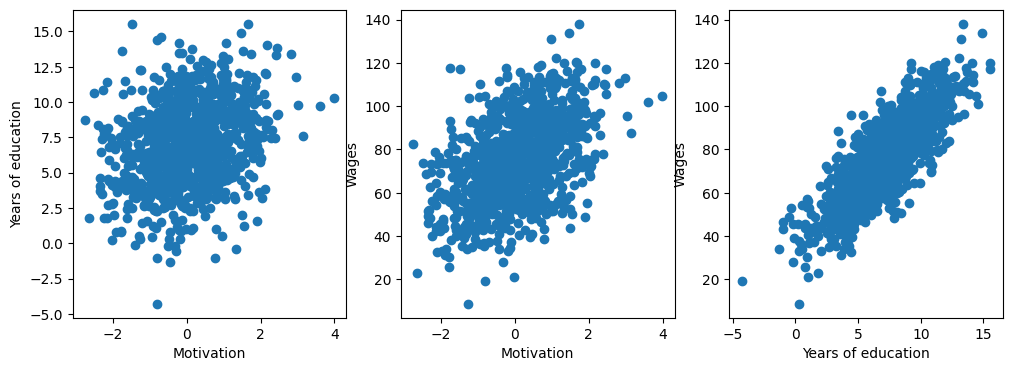

In [63]:
fig,ax = plt.subplots(1,3, figsize=[12,4])
ax[0].plot(M, E, 'o')
ax[0].set_xlabel("Motivation")
ax[0].set_ylabel("Years of education")

ax[1].plot(M, W, 'o')
ax[1].set_xlabel("Motivation")
ax[1].set_ylabel("Wages")

ax[2].plot(E, W, 'o')
ax[2].set_xlabel("Years of education")
ax[2].set_ylabel("Wages")

In [64]:
# Naive OLS gives a biased estimate.
# True value of $\gamma_1$ is 10, but that's not even in our confidence interval.
ols_y = W
ols_x = sm.add_constant(E)
model = sm.OLS(ols_y, ols_x)
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.666
Model:                            OLS   Adj. R-squared:                  0.666
Method:                 Least Squares   F-statistic:                     1994.
Date:                Wed, 06 May 2026   Prob (F-statistic):          3.66e-240
Time:                        22:04:16   Log-Likelihood:                -3843.9
No. Observations:                1000   AIC:                             7692.
Df Residuals:                     998   BIC:                             7702.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         36.6014      0.937     39.077      0.000      34.763      38.439
x1             5.4776      0.123     44.652      0.000       5.237       5.718
==============================================================================
Omnibus:                        1.386   Durbin-Watson:                   1.875
Prob(Omnibus):                  0.500   Jarque-Bera (JB):                1.451
Skew:                           0.066   Prob(JB):                        0.484
Kurtosis:                       2.867   Cond. No.                         20.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# Introducing instrumental variables
Distance to college has a causal effect on how much education you get. But it's not necessarily related to ability. 

**Relevance assumption**: The instrument (distance to college) has a causal effect on the treatment.

**Exogeneity assumption**: The instrument is randomly assigned to units - it's unrelated to the residual.

**Exclusion restriction**: The instrument does not have a direct causal effect on the outcome.

This latter is debatable - proximity to college may mean a higher chance of being raised by a highly skilled academic, which could affect motivation. Put this aside for now.

Text(0, 0.5, 'Years of education')

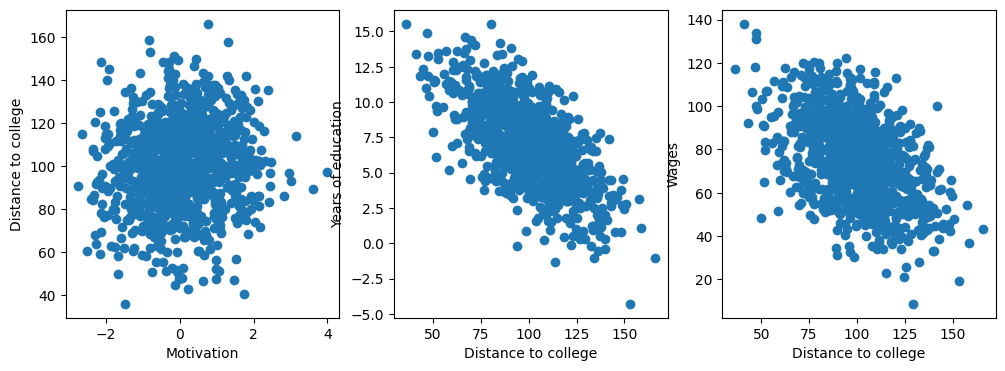

In [65]:
fig,ax = plt.subplots(1,3, figsize=[12,4])
ax[0].plot(M, D, 'o')
ax[0].set_xlabel("Motivation")
ax[0].set_ylabel("Distance to college")

ax[2].plot(D, W, 'o')
ax[2].set_xlabel("Distance to college")
ax[2].set_ylabel("Wages")

ax[1].plot(D, E, 'o')
ax[1].set_xlabel("Distance to college")
ax[1].set_ylabel("Years of education")

# Estimating the causal effect with 2SLS

In [70]:
model1 = sm.OLS(E, sm.add_constant(D))
result1 = model1.fit()
E_hat = result1.predict()
model2 = sm.OLS(W, sm.add_constant(E_hat))
result2 = model2.fit()
result2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.215
Model:                            OLS   Adj. R-squared:                  0.215
Method:                 Least Squares   F-statistic:                     273.8
Date:                Wed, 06 May 2026   Prob (F-statistic):           1.55e-54
Time:                        22:08:47   Log-Likelihood:                -4271.6
No. Observations:                1000   AIC:                             8547.
Df Residuals:                     998   BIC:                             8557.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         41.8894      2.090     20.046      0.000      37.789      45.990
x1             4.7282      0.286     16.548      0.000       4.167       5.289
==============================================================================
Omnibus:                        4.772   Durbin-Watson:                   1.910
Prob(Omnibus):                  0.092   Jarque-Bera (JB):                3.754
Skew:                          -0.016   Prob(JB):                        0.153
Kurtosis:                       2.702   Cond. No.                         28.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [69]:
# Using built in library
from statsmodels.sandbox.regression.gmm import IV2SLS
model_2sls = IV2SLS(W, sm.add_constant(E), instrument=sm.add_constant(D))
result_2sls = model_2sls.fit()
result_2sls.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                          IV2SLS Regression Results                           
==============================================================================
Dep. Variable:                      y   R-squared:                       0.654
Model:                         IV2SLS   Adj. R-squared:                  0.654
Method:                     Two Stage   F-statistic:                     620.9
                        Least Squares   Prob (F-statistic):          5.92e-107
Date:                Wed, 06 May 2026                                         
Time:                        22:08:39                                         
No. Observations:                1000                                         
Df Residuals:                     998                                         
Df Model:                           1                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         41.8894      1.388     30.187      0.000      39.166      44.612
x1             4.7282      0.190     24.918      0.000       4.356       5.101
==============================================================================
Omnibus:                        1.757   Durbin-Watson:                   1.894
Prob(Omnibus):                  0.415   Jarque-Bera (JB):                1.813
Skew:                           0.078   Prob(JB):                        0.404
Kurtosis:                       2.862   Cond. No.                         20.3
==============================================================================
"""